In [1]:
# Cell 1: Imports + config
import glob
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Print cwd for debugging
print("Current working directory:", os.getcwd())

# ---- CONFIG ----
# DATA_GLOB = "./nki_clean/gemm_nki_benchmark*.csv"
DATA_GLOB = "./logs/xla/cond_worldsize32_rank*.csv"   
FILTER_DTYPE = None                      # e.g. "fp16", "bf16", "fp32", or None for no filter
FILTER_USE_BIAS = None                   # e.g. 0/1 or None for no filter

# Plot style
CMAP = "jet"                             # similar look to your screenshot
V_MIN, V_MAX = 0, 90                    # set to None/None to auto-scale
POINT_SIZE = 2                           # smaller if very dense
ALPHA = 0.9                              # tweak transparency


Current working directory: /fsx/linshuy2/neuronx-distributed-training/examples/benchmarks/ops


In [2]:
# Cell 2: Load & merge all CSVs (no header)
cols = ["M", "K", "N", "use_bias", "dtype", "avg_tflops", "avg_ms"]
# cols = ["M", "K", "N", "dtype", "avg_tflops", "avg_ms"]


files = sorted(glob.glob(DATA_GLOB))
if not files:
    raise FileNotFoundError(f"No files matched: {DATA_GLOB}")

print(f"Loading {len(files)} files...")

dfs = []
for f in files:
    df = pd.read_csv(
        f,
        header=None,
        names=cols,
        dtype={0: np.int64, 1: np.int64, 2: np.int64, 3: np.int64, 4: str, 5: float, 6: float},
        # dtype={0: np.int64, 1: np.int64, 2: np.int64, 3: str, 4: float, 5: float},
        # If your files can have blank lines or weird rows, uncomment:
        on_bad_lines="skip",
    )
    df["source_file"] = os.path.basename(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Basic cleanup
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["M", "K", "avg_tflops"])

# Optional: enforce/validate M == N
neq = (data["M"] != data["N"]).sum()
if neq:
    print(f"Warning: found {neq} rows where M != N. Keeping them, but you can drop if desired.")
    # data = data[data["M"] == data["N"]]

# Optional filters
if FILTER_DTYPE is not None:
    data = data[data["dtype"] == FILTER_DTYPE]
if FILTER_USE_BIAS is not None:
    data = data[data["use_bias"] == FILTER_USE_BIAS]

print("Loaded rows:", len(data))
data.head()

key_cols = ["M", "K", "N", "dtype"]
if "use_bias" in data.columns:
    key_cols.insert(3, "use_bias")

# make sure it's numeric
data["avg_tflops"] = pd.to_numeric(data["avg_tflops"], errors="coerce")
data = data.dropna(subset=["avg_tflops"])

# keep row with max avg_tflops per key
data = (
    data.sort_values("avg_tflops", kind="mergesort")  # stable sort
        .drop_duplicates(subset=key_cols, keep="last")
        .reset_index(drop=True)
)

print("After dedupe:", len(data))


Loading 1024 files...
Loaded rows: 236328
After dedupe: 236328


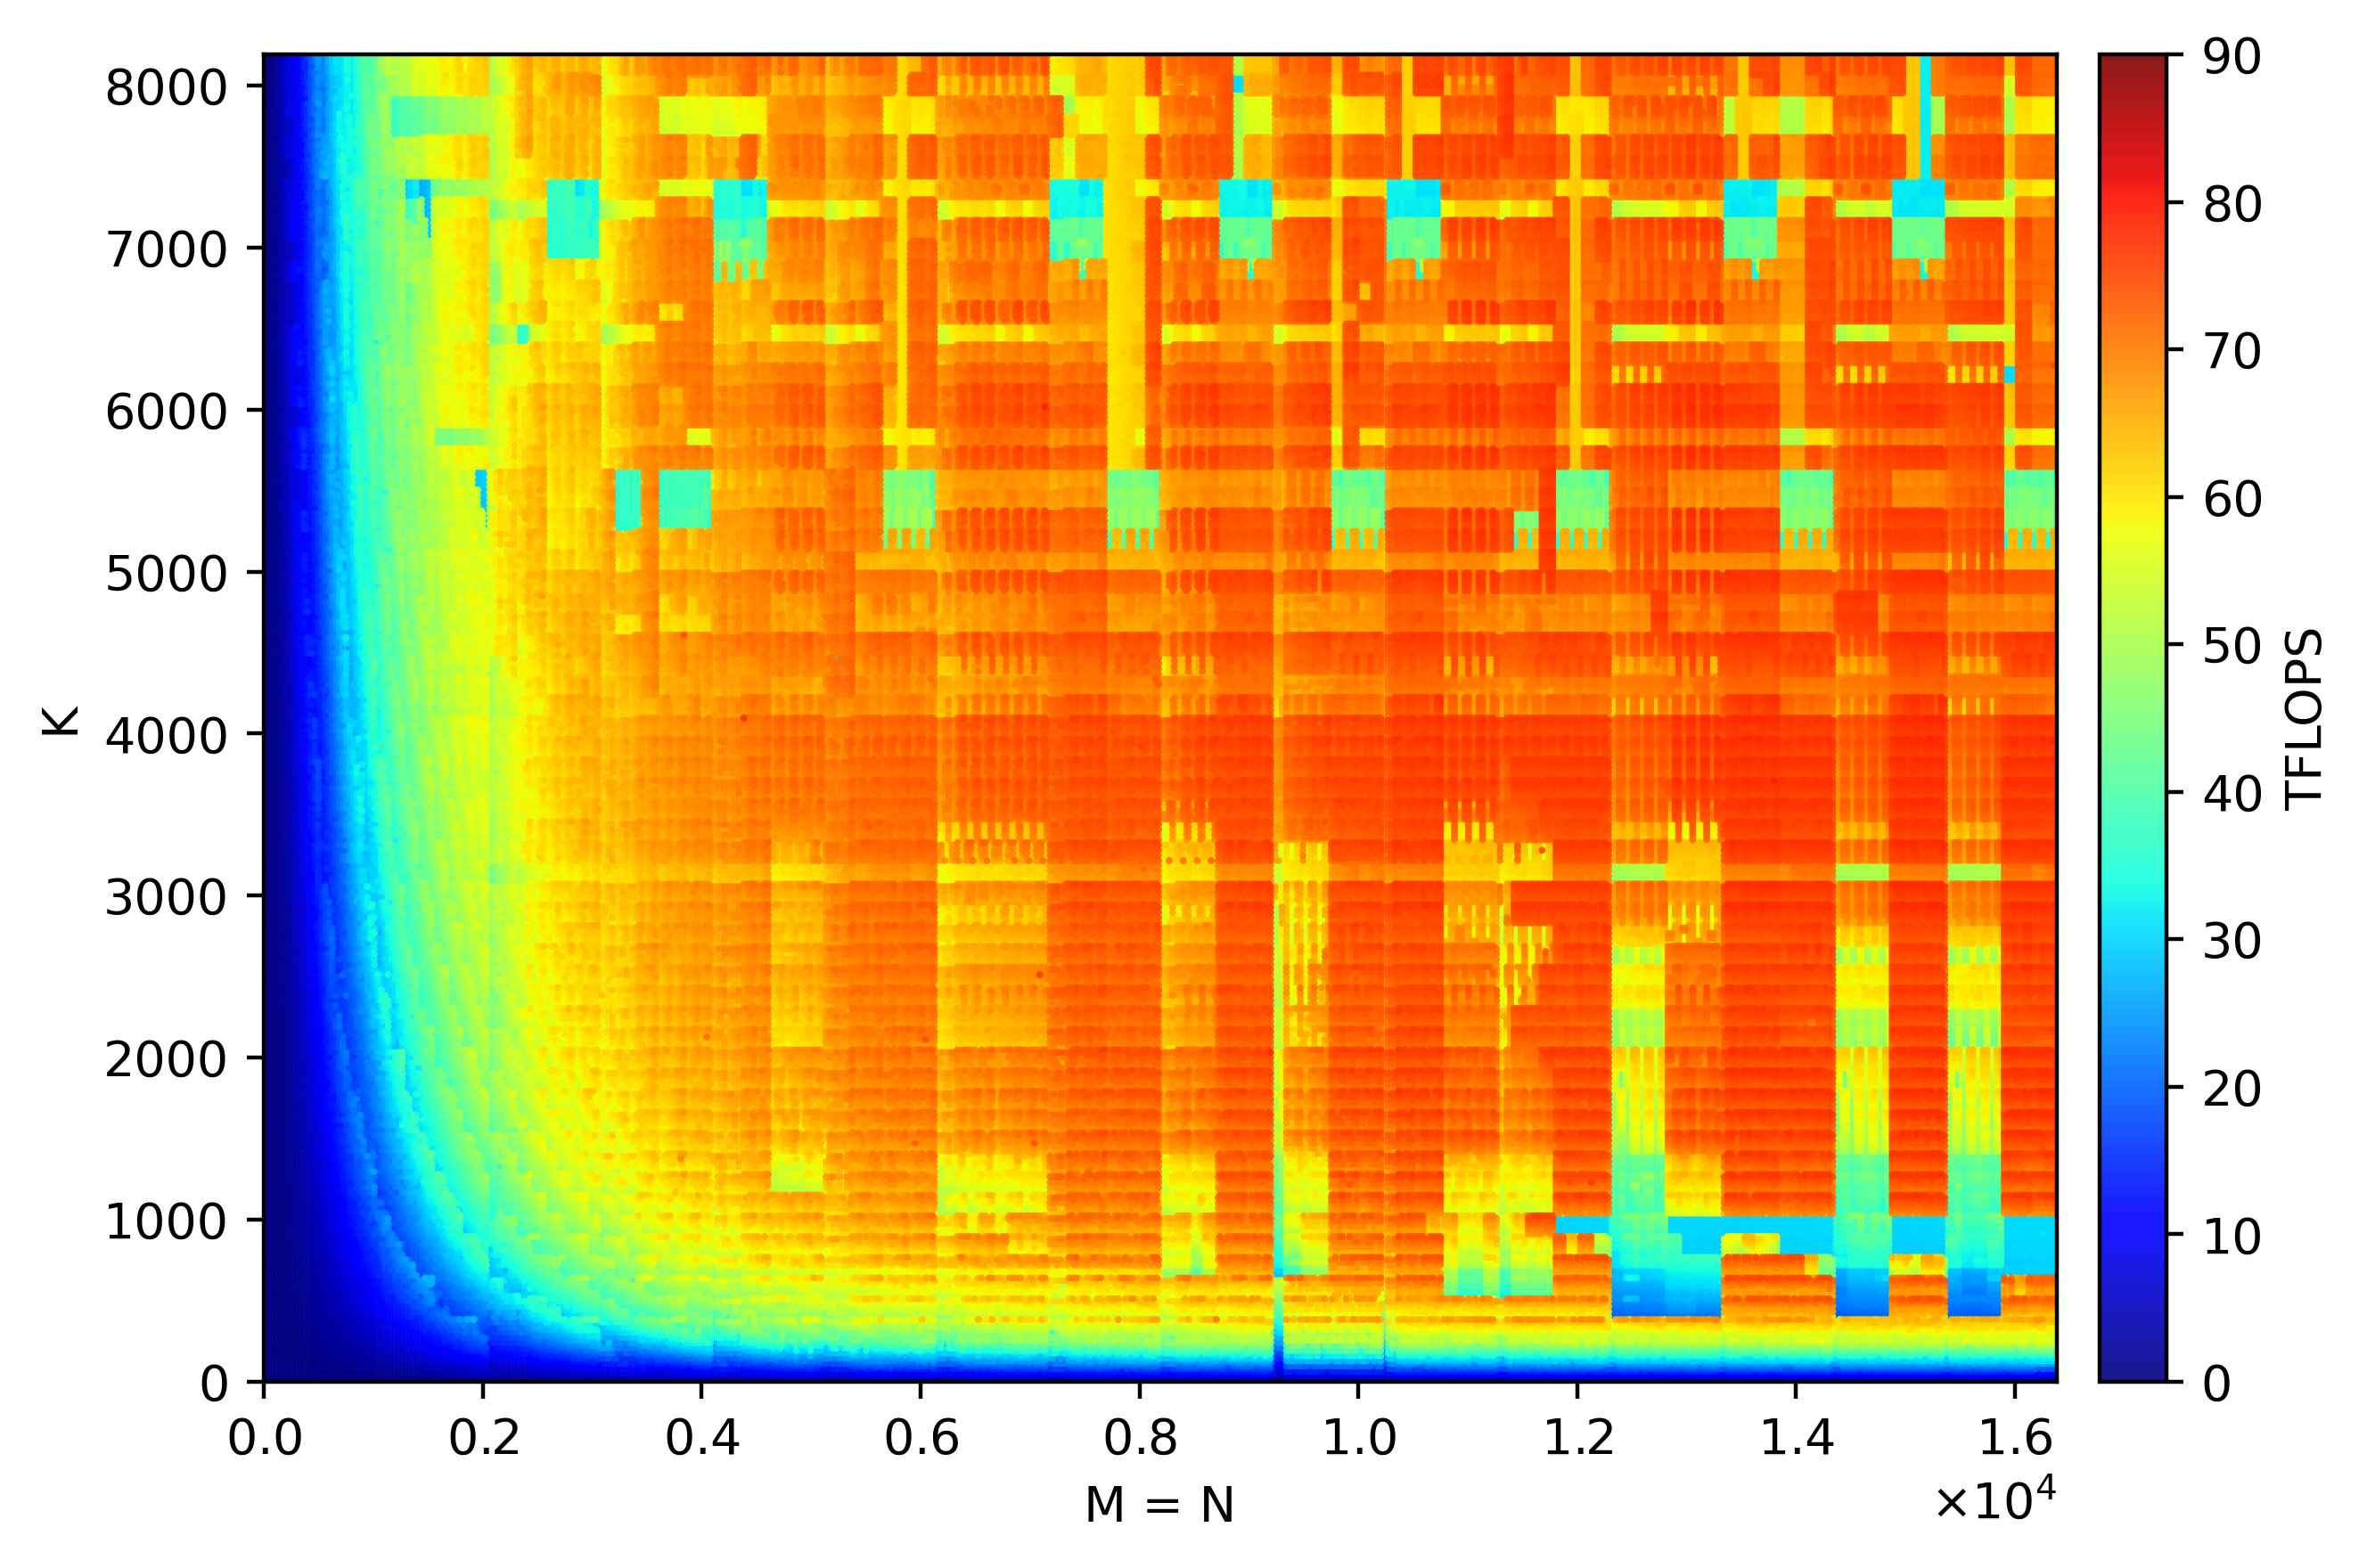

In [3]:
# Cell 3: Scatter "heatmap" (points colored by TFLOPS) — closest to your screenshot
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=400)

sc = ax.scatter(
    data["M"].to_numpy(),
    data["K"].to_numpy(),
    c=data["avg_tflops"].to_numpy(),
    s=POINT_SIZE,
    alpha=ALPHA,
    cmap=CMAP,
    vmin=V_MIN,
    vmax=V_MAX,
    linewidths=0,
    rasterized=True,  # makes huge point clouds much lighter in vector outputs
)

ax.set_xlabel("M = N")
ax.set_ylabel("K")

# Format x-axis like "×10^5"
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0), useMathText=True)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("TFLOPS")

ax.grid(False)
ax.set_xlim(left=0, right=data["M"].max())
ax.set_ylim(bottom=0, top=data["K"].max())

plt.tight_layout()
plt.show()


In [4]:
import numpy as np
import math

def moe_m_distribution(
    B: int,
    S: int,
    E: int,
    top_k: int,
    capacity_factor: float,
    mode: str = "truncated",   # "truncated" -> min(X,C), "padded" -> always C
    n_samples: int = 200_000,
    seed: int = 0,
):
    """
    Returns samples of M_gemm for one expert under balanced routing.

    X ~ Binomial(n=k*T, p=1/E)
    C = ceil(capacity_factor * (k*T/E))
    M_gemm = min(X,C) (truncated) OR C (padded)
    """
    rng = np.random.default_rng(seed)

    T = B * S
    n = top_k * T
    p = 1.0 / E

    mu = n * p
    C = int(math.ceil(capacity_factor * mu))

    if mode == "padded":
        M = np.full(n_samples, C, dtype=int)
    elif mode == "truncated":
        X = rng.binomial(n=n, p=p, size=n_samples)
        M = np.minimum(X, C).astype(int)
    else:
        raise ValueError("mode must be 'truncated' or 'padded'")

    stats = {
        "T": T,
        "n_assignments": n,
        "p": p,
        "mu": mu,
        "capacity_C": C,
        "mean_M": float(M.mean()),
        "std_M": float(M.std()),
    }
    return M, stats


def percentile_ranges(M: np.ndarray, cuts=(5, 25, 75, 95)):
    """
    Convert samples -> small/medium/large ranges based on percentiles.
    Default:
      small  = [p5,  p25]
      medium = [p25, p75]
      large  = [p75, p95]
    """
    p = np.percentile(M, cuts).astype(int)
    p5, p25, p75, p95 = p
    return {
        "small":  (int(p5),  int(p25)),
        "medium": (int(p25), int(p75)),
        "large":  (int(p75), int(p95)),
        "pcts": {"p5": int(p5), "p25": int(p25), "p75": int(p75), "p95": int(p95)},
    }


def make_boxes_from_ranges(ranges, K_value, K_band=0):
    """
    Convert M ranges -> rectangle specs for your overlay.
    If you want a thin vertical band at exact K, keep K_band small.
    """
    boxes = {}
    for name, (m0, m1) in ranges.items():
        if name == "pcts":
            continue
        k0 = K_value - K_band
        k1 = K_value + K_band
        boxes[name] = [(m0, m1, k0, k1)]
    return boxes


# ============================
# Example usage (fill yours in)
# ============================

# Known settings (EDIT THESE)
B = 8
S = 2048
E = 64
top_k = 2
capacity_factor = 1.25

# Which GEMM are you annotating?
d_model = 8192
# d_ff = 28672   # if you want to annotate the other FFN GEMM instead

M_samps, stats = moe_m_distribution(
    B=B, S=S, E=E, top_k=top_k, capacity_factor=capacity_factor,
    mode="truncated",      # "padded" if your kernels always run at capacity
    n_samples=200_000,
    seed=0,
)

ranges = percentile_ranges(M_samps, cuts=(5, 25, 75, 95))

print("Stats:", stats)
print("Ranges:", ranges)

# Turn into your plotting boxes
MOE_REGIONS = make_boxes_from_ranges(ranges, K_value=d_model, K_band=0)

# Now MOE_REGIONS["small"], ["medium"], ["large"] are ready to plug into your overlay code.
print("Boxes:", MOE_REGIONS)

Stats: {'T': 16384, 'n_assignments': 32768, 'p': 0.015625, 'mu': 512.0, 'capacity_C': 640, 'mean_M': 512.04315, 'std_M': 22.460729241890167}
Ranges: {'small': (475, 497), 'medium': (497, 527), 'large': (527, 549), 'pcts': {'p5': 475, 'p25': 497, 'p75': 527, 'p95': 549}}


ValueError: too many values to unpack (expected 2)

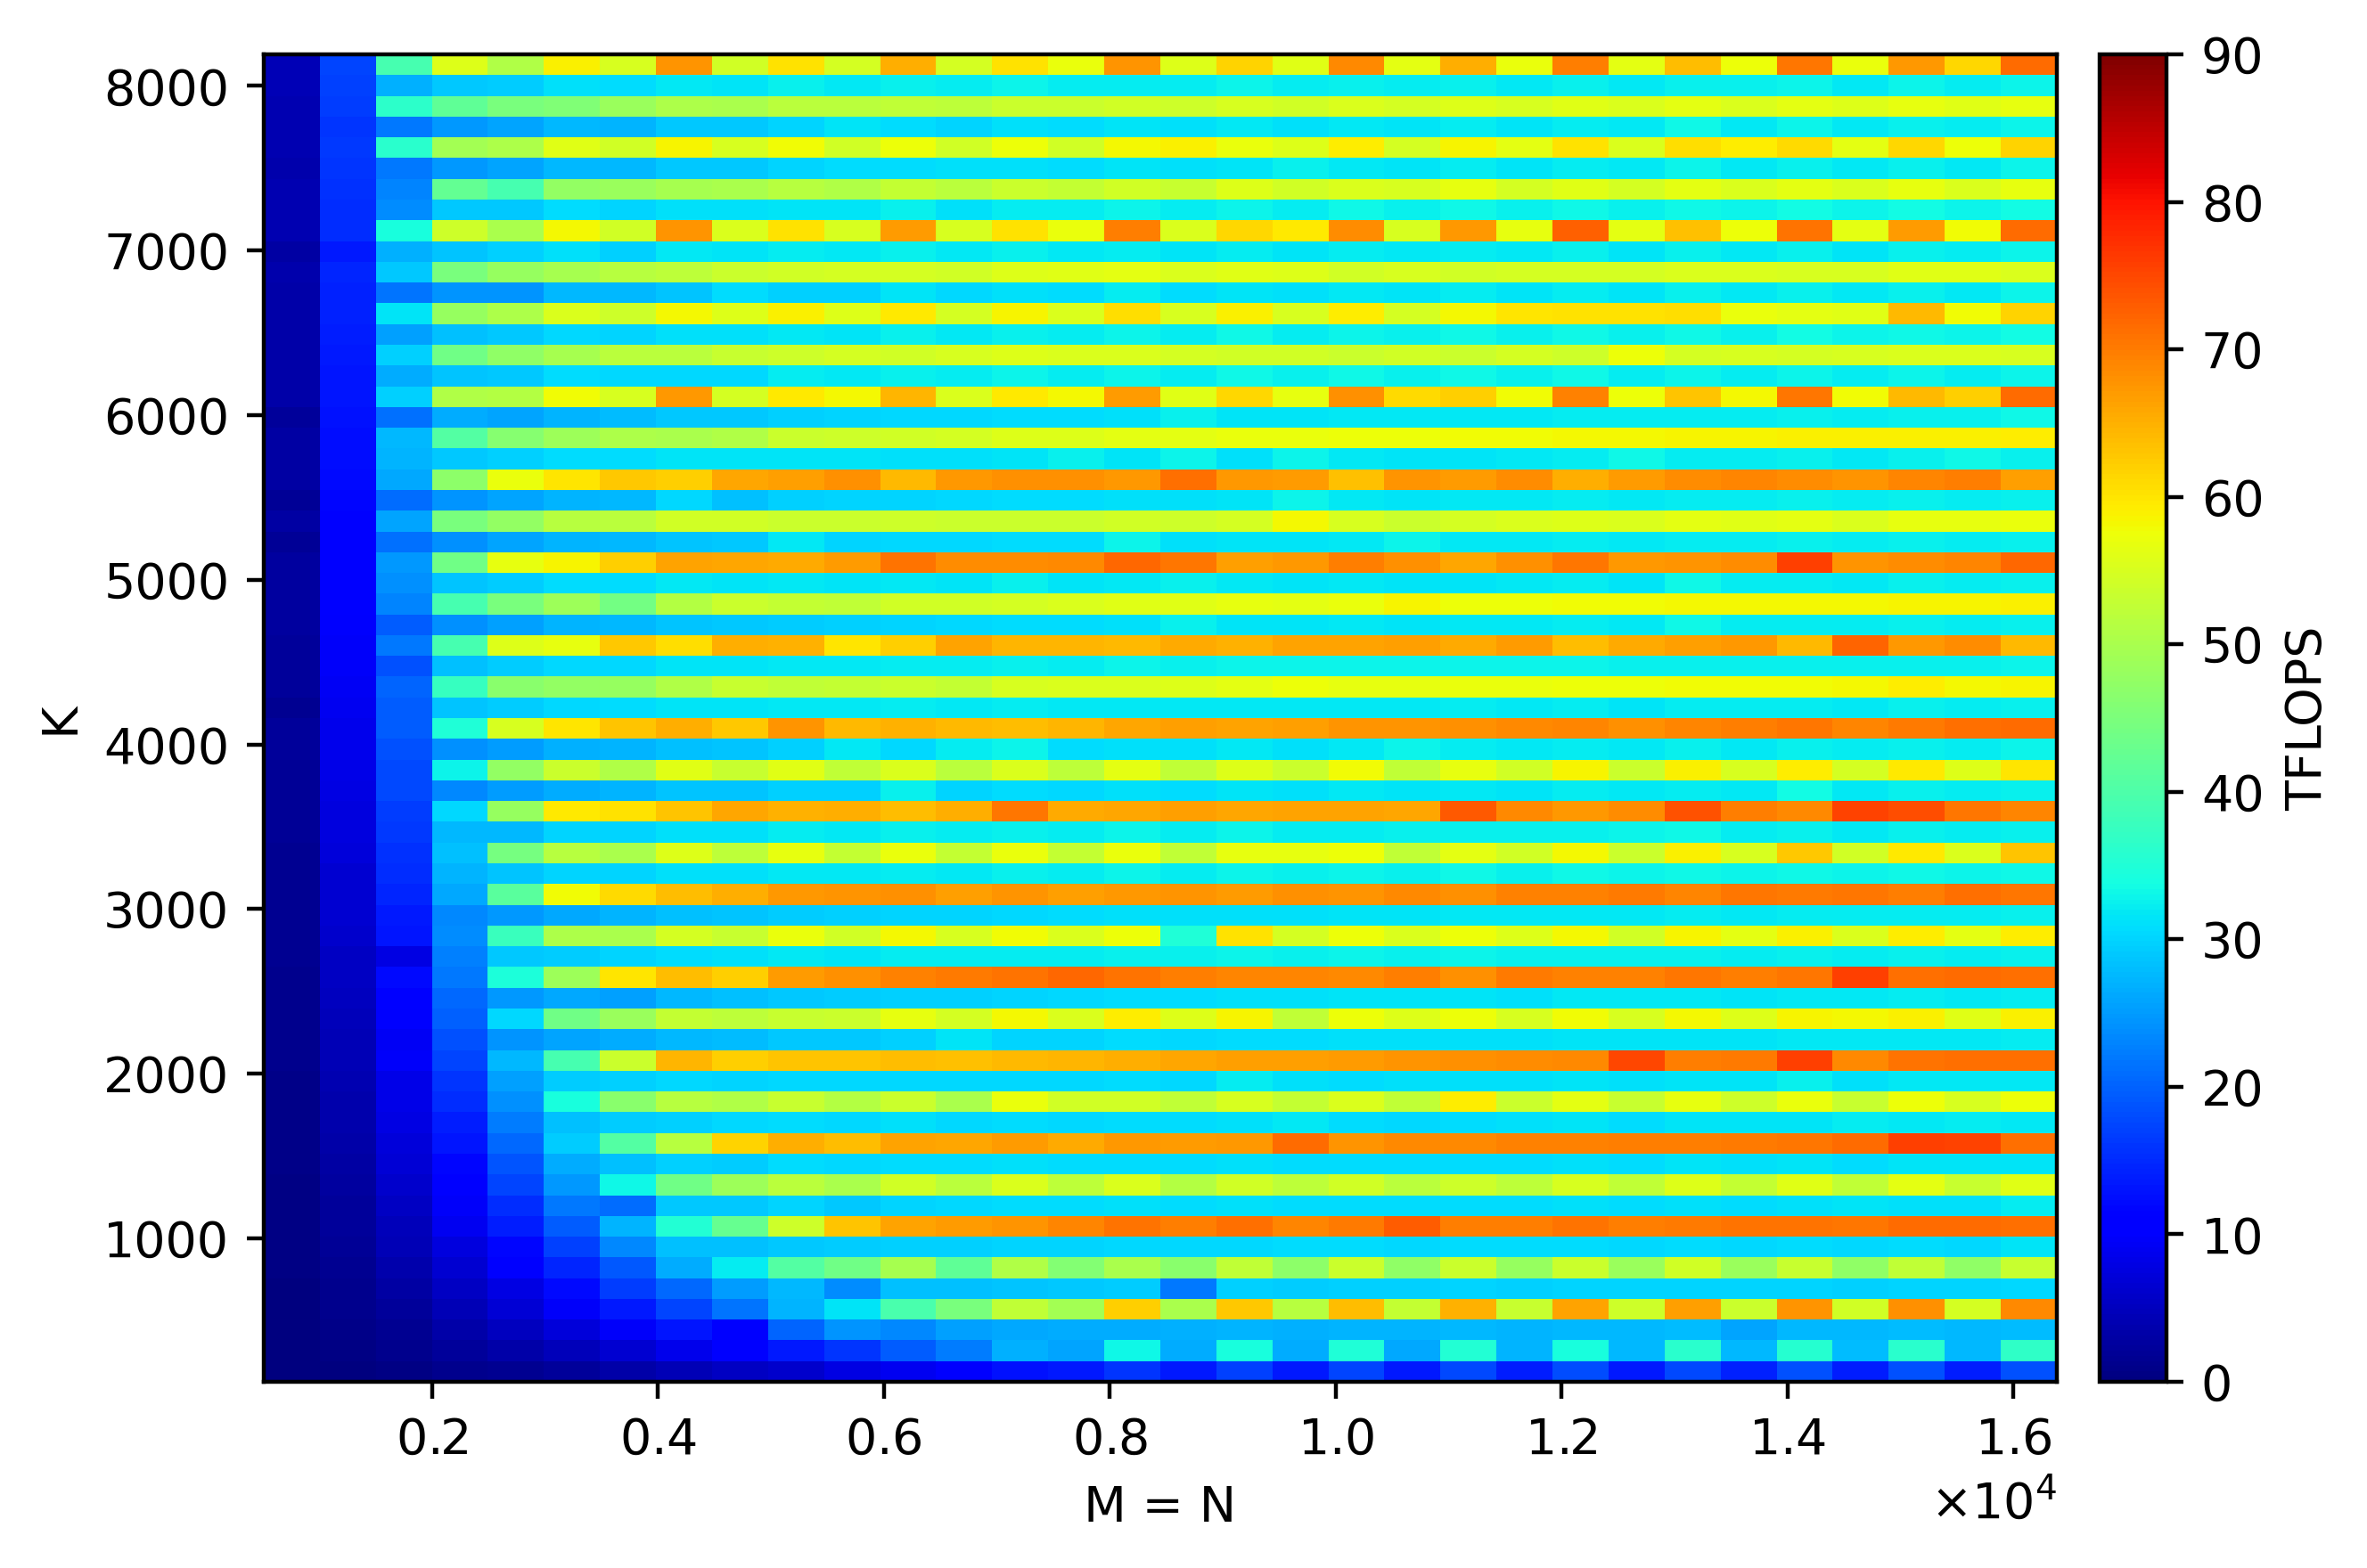

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

M_STEP = 512
K_STEP = 128

# If you're already exactly on-stride, this is redundant but harmless:
df = data.copy()
df["M_bin"] = (df["M"] // M_STEP) * M_STEP
df["K_bin"] = (df["K"] // K_STEP) * K_STEP

# Aggregate duplicates (if any)
g = df.groupby(["K_bin", "M_bin"], as_index=False)["avg_tflops"].mean()

# Pivot to matrix: rows=K, cols=M
Z = g.pivot(index="K_bin", columns="M_bin", values="avg_tflops").sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=400)
im = ax.imshow(
    Z.to_numpy(),
    origin="lower",
    aspect="auto",
    cmap=CMAP, vmin=V_MIN, vmax=V_MAX,
    interpolation="nearest",
    extent=[Z.columns.min(), Z.columns.max(), Z.index.min(), Z.index.max()],
)

ax.set_xlabel("M = N")
ax.set_ylabel("K")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0), useMathText=True)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("TFLOPS")

plt.tight_layout()
plt.show()


In [6]:
data.head

<bound method NDFrame.head of           M     K      N          dtype  avg_tflops     avg_ms  \
0       512   128    512  torch.float16    0.046170   1.453509   
1       512   256    512  torch.float16    0.137706   0.974672   
2       512   384    512  torch.float16    0.205948   0.977558   
3       512   512    512  torch.float16    0.264252   1.015832   
4      1024   128   1024  torch.float16    0.269755   0.995110   
...     ...   ...    ...            ...         ...        ...   
2043  15872  1536  15872  torch.float16   75.268141  10.281899   
2044  15360  1536  15360  torch.float16   75.590460   9.588191   
2045  14336  5120  14336  torch.float16   75.601743  27.837109   
2046  14848  2560  14848  torch.float16   75.622710  14.926351   
2047  14336  2048  14336  torch.float16   75.666937  11.125250   

                                            source_file  
0     gemm_nki_benchmark_k128-8192-128_m512-2048-512...  
1     gemm_nki_benchmark_k128-8192-128_m512-2048-512...  
2  